<a href="https://colab.research.google.com/github/gabecerram/Analitica_de_datos/blob/main/3_Modelo_de_clusterizaci%C3%B3n_(k_means).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caso de estudio**

Una entidad financiera (FINTECH) quiere implementar un modelo de clustering K-means para mejorar la preaprobación de créditos de consumo de sus solicitantes de este tipo de créditos. Para este proceso vamos a utilizar las variables:

* Edad: Indica el número de años que posee una persona, o el tiempo que usted lleva en el sistema financiero.
* Ingresos: Engloba todos los ingresos que recibe una persona además de sí posee salario mensual (USD).
* Egresos: Son los gastos mensuales del solicitante. Gastos de personas a cargo, hijos y servicios públicos.
* Monto (EAD): Indica el dinero que una persona solicita a una entidad financiera como crédito.

0. Se procede con la carga de las librerias de trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Herramienta para gráficas estadísticas
from sklearn.cluster import KMeans # Herramienta de clustering

1. Se cargan los datos de trabajo


<Axes: >

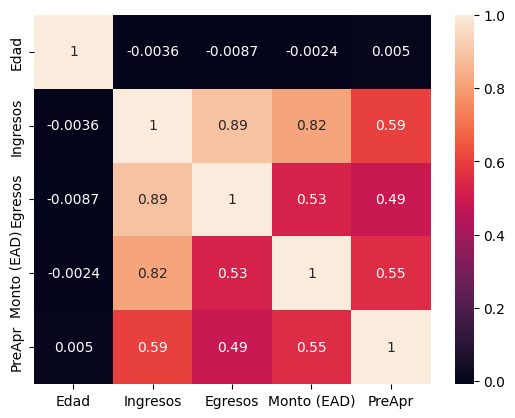

In [ ]:
nxl="/content/1. SolicitantesCrédito(USD) Sin modificaciones .xlsx"
XDB=pd.read_excel(nxl,sheet_name=1) #Base AAA
XD=XDB.iloc[:,[1,10,11,25]] #Datos de entrada
yd=XDB.iloc[:,[32]]
display(XD)

# Determinamos la correlación entre las variables
XDB2=XDB.iloc[:,[1,10,11,25,32]]
sns.heatmap(XDB2.corr(),annot=True)

2. Se procede con la implementación del modelo K- means

In [ ]:
np.random.seed(42) # Esto permite generar las mismas semillas para todos.
NC=5 # Segmentos de perfiles o clientes
mkm=KMeans(n_clusters=NC, random_state=0).fit(XD)
mkm.fit(XD,yd) #El modelo busca la mejor entre la entrada y la salida

#Obtenemos las características de cada grupo
#Representa los perfiles de las personas mkm.cluster_center_ que encontró el modelo
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla)

#Para saber los porcentajes de PreApro o PreNEg por segmento, sucursal o perfil.
ydp=mkm.labels_ #Esto me indica en que cluster queda clasificado cada rato
NDc=np.bincount(ydp) #Nuemero de datos por segmentos
print("El nemero de datos por clientde",NDc)

,Edad,Ingresos,Egresos,Monto (EAD)
0,41.072289,236.551926,207.188730,170.964605
1,40.904412,1930.511433,2026.035991,1140.801060
2,40.810309,1375.632247,823.620060,1499.463671
3,40.963955,1167.564578,1226.937727,655.305271
4,41.130456,700.941819,594.228751,529.667652


array([3, 0, 4, ..., 4, 4, 3], dtype=int32)

3. Porcentajes de preaprobación

In [ ]:
XDB2 ["Cluster"]=ydp
display(ydp)
#determinar el numero de preaprobados y prenegados por cluster
NApr=XDB2.groupby("Cluster").agg({"PreApr": lambda x:(x==1).sum()})
NPrn=XDB2.groupby("Cluster").agg({"PreApr": lambda x:(x==0).sum()})

#Para que la desición sea en porcentaje
NApr2=NApr/(NApr+NPrn);NPrn2=NPrn/(NApr+NPrn)
df2=pd.DataFrame(np.column_stack((NApr2,NPrn2)),columns=["PreApr","PreNeg"])
display(df2)



/tmp/ipython-input-568/248036595.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XDB2 ["Cluster"]=ydp


array([3, 0, 4, ..., 4, 4, 3], dtype=int32)

,PreApr,PreNeg
0,0.129639,0.870361
1,0.959559,0.040441
2,0.973196,0.026804
3,0.767250,0.232750
4,0.557136,0.442864


4. ¿Qué pasa si aparece una nueva persona?
Edad:30 , Ingresos: 500 , Egresos: 200 , Monto: 150.

In [ ]:
import warnings
warnings.filterwarnings("ignore")
nueva_persona=np.array([[30,500,200,150]])
ydp=mkm.predict(nueva_persona)
NCl=ydp[0] # Cluster al que pertenece una persona
print("La persona pertenece al cluster:", ydp)
print("El porcentaje de preaprobación para la nueva persona es:", NApr.iloc[NCl])
print("El porcentaje de prenegación para la nueva persona es:", NPrn.iloc[NCl])

La persona pertenece al cluster: [0]
El porcentaje de preaprobación para la nueva persona es: PreApr    269
Name: 0, dtype: int64
El porcentaje de prenegación para la nueva persona es: PreApr    1806
Name: 0, dtype: int64


5. Se procede con la grafica de los cluster utilizando las variables ingresos y egresos.


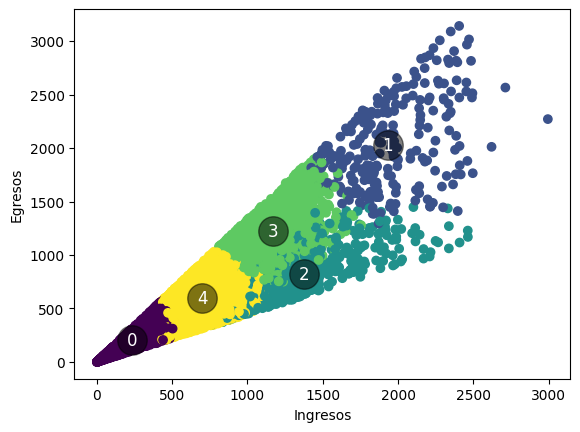

In [ ]:
centers=mkm.cluster_centers_ #Centrosides, perfil o segmento
ing=np.array(XD.iloc[:,1]); egr=np.array(XD.iloc[:,2])

plt.figure()
plt.scatter(ing,egr,c=mkm.labels_,cmap="viridis")
plt.scatter(centers[:,1],centers[:,2],c="black",s=450,alpha=0.5)
plt.xlabel("Ingresos")
plt.ylabel("Egresos")


for i, center in enumerate(centers):
  plt.text(center[1], center[2], str(i), color="white", fontsize=12, ha="center", va="center")

plt.show()

#**Analisis de resultados**

En el hitmap se puede observar que las variables que tienen una mayor correclación entre ellas son las variables de ingresos y egresos  con un 89%. Esto indica qie si una variabke aumenta su valor , la otra tambien incrementa (si gano mucho, gasto mucho).

Otra correlación de relevancia es una correlación entre ingresos y monto (0.82), personas con altos ingresos, piden montos mayores  (bajos ingresos - montos menores).

Se destaca que la varibale que tiene una mayor correlación con la variable PreApro (salida) es ka variable ingresos (0.59)

De acuerdo con los segmentos o clusters arrojados por el modeo, podemos observar que el cluster1 y 2 son los que poseen ingresos más altos 1943 y 1378 respectivamente, cluster que igualmente son los que tienen la menor cantidad de solicitantes del crédito con 264 y 485. Se destaca el primer cluster, el cual agrupa a las personas con menos ingresos (242), pero es el grupo el que posee la mayor cantidad de solicitantes de credito 2027.

Se puede observar que el cluster 1 y 2 agrupan las probabilidades mas altas frente a la preaprobación de los creditos con un 96% y 97% de preaprobación respectivamente.

Es importante mencionar que e lcluster cero tuvo los menores porcentajes de preaprovación, esto promovido por los menores ingresos de las personas que hacen parte de este cluster.